In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [4]:
df=pd.read_csv('solarpower.csv')
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [5]:
df.shape

(2920, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [7]:
df.describe()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.261547,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


In [8]:
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    1
average-pressure-(period)      0
power-generated                0
dtype: int64

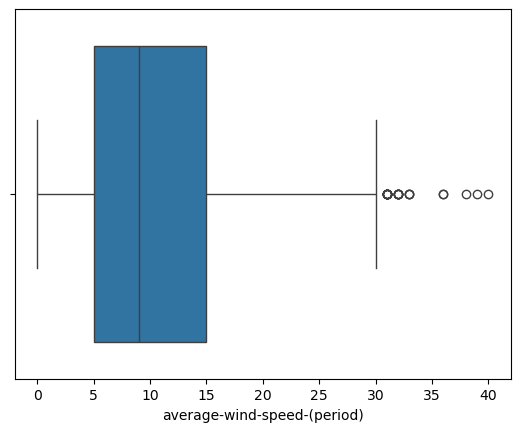

In [9]:
sn.boxplot(x=df["average-wind-speed-(period)"])
plt.show()

In [10]:
df["average-wind-speed-(period)"] = (df["average-wind-speed-(period)"].fillna(df["average-wind-speed-(period)"].median()))

In [11]:
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    0
average-pressure-(period)      0
power-generated                0
dtype: int64

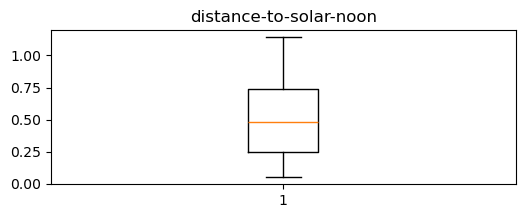

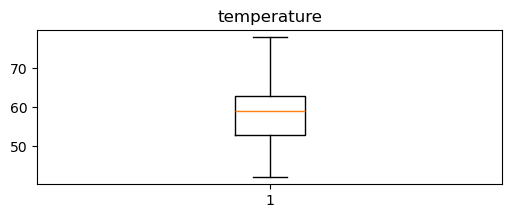

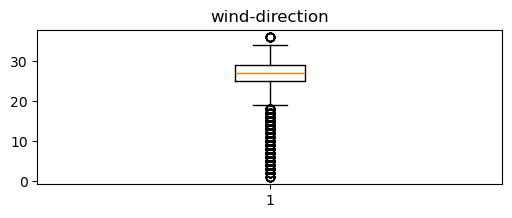

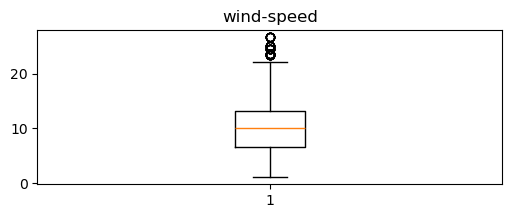

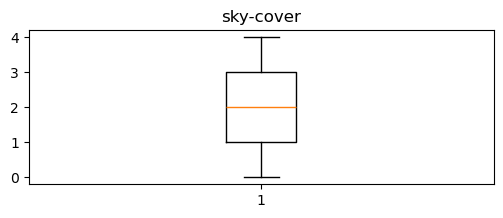

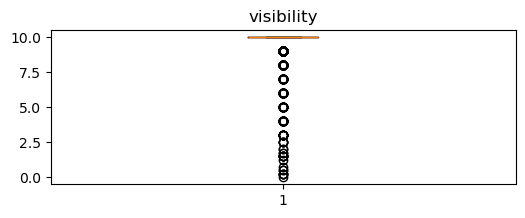

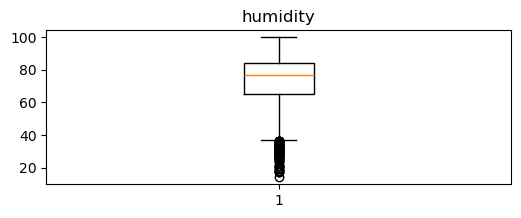

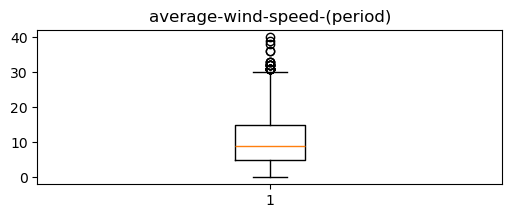

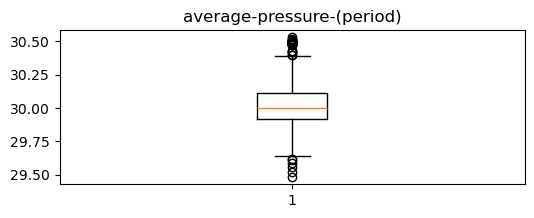

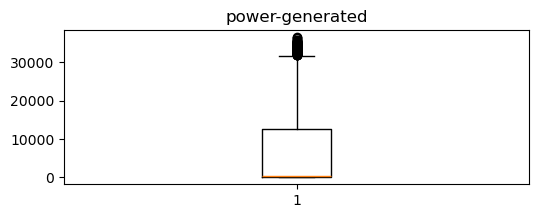

In [12]:
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6,2))
    plt.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [15]:
for col in df.select_dtypes(include='number').columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outliers=df[(df[col]<lower) | (df[col]>upper)]
    print(f'{col}:{len(outliers)}outliers')

distance-to-solar-noon:0outliers
temperature:0outliers
wind-direction:528outliers
wind-speed:40outliers
sky-cover:0outliers
visibility:429outliers
humidity:83outliers
average-wind-speed-(period):25outliers
average-pressure-(period):31outliers
power-generated:107outliers


In [16]:
df.duplicated().sum()

np.int64(0)

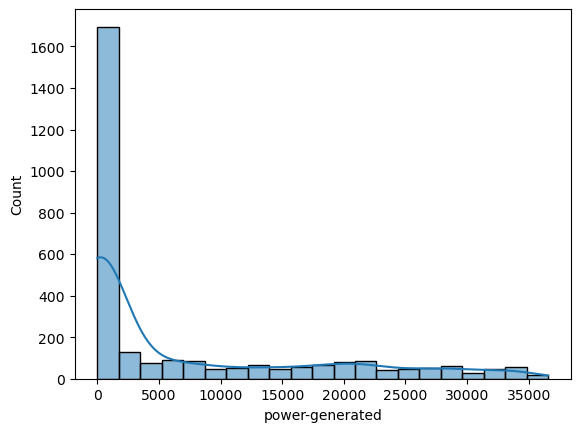

In [17]:
sn.histplot(df['power-generated'],kde=True)
plt.show()

In [18]:
corr=df.corr(numeric_only=True)
corr['power-generated'].sort_values(ascending=False)

power-generated                1.000000
average-wind-speed-(period)    0.278188
wind-direction                 0.146788
wind-speed                     0.142641
temperature                    0.132193
visibility                     0.076536
average-pressure-(period)     -0.036771
sky-cover                     -0.187236
humidity                      -0.522545
distance-to-solar-noon        -0.746681
Name: power-generated, dtype: float64

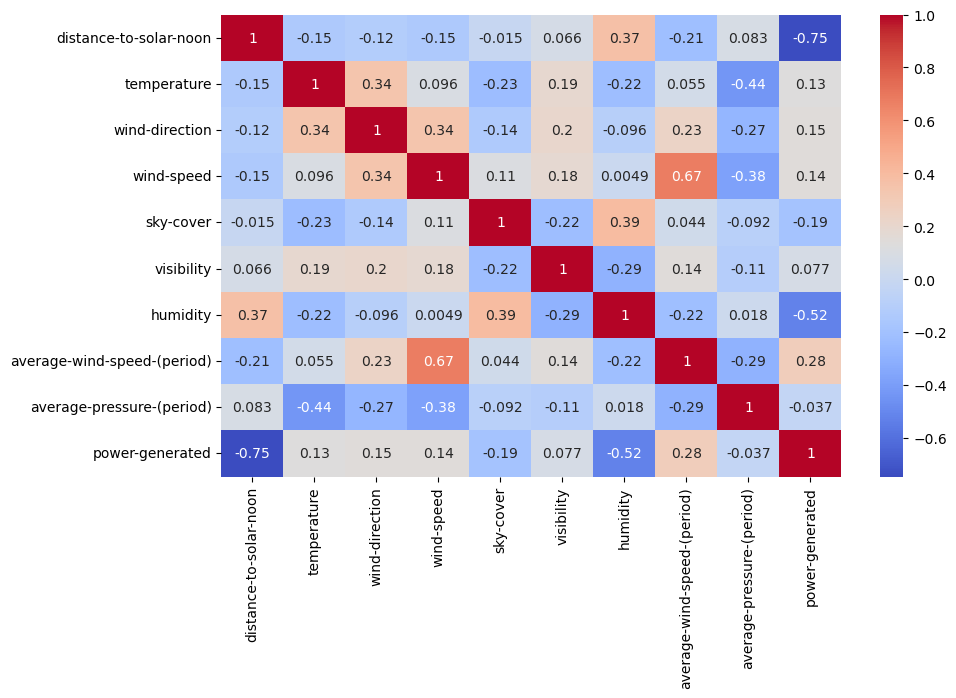

In [19]:
plt.figure(figsize=(10,6))
sn.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()


In [20]:
x=df.drop('power-generated',axis=1)
y=df['power-generated']

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [51]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [52]:
ypred=model.predict(x_test)
ypred

array([ 1.68144847e+04,  1.00472303e+04,  5.11882675e+03,  6.93305585e+03,
        7.69310377e+03,  2.06732592e+04,  3.30163432e+02, -2.49936169e+03,
        2.46763072e+03,  3.06268414e+03,  7.10220095e+03, -1.55421564e+03,
        1.76680371e+04,  1.91058870e+04,  9.97585342e+03, -8.36039882e+03,
       -9.71838448e+03,  7.55930259e+03,  7.23663393e+03,  6.20199717e+03,
        1.52307825e+04, -8.89960284e+03,  1.25682524e+04,  5.61953831e+03,
        1.49812970e+04,  4.23423579e+03,  1.64872414e+04,  3.47022432e+03,
        1.86807033e+04,  1.82059072e+04,  1.75970148e+04,  2.34268056e+04,
        1.40073244e+04,  1.79619103e+03, -4.90481723e+02,  1.42922853e+04,
       -1.02629192e+03,  1.06471548e+04,  2.37261259e+04, -6.94753212e+03,
        1.27714376e+04,  5.80629623e+02,  1.70739830e+04, -9.56078005e+02,
        7.95601343e+03,  1.47555470e+04,  1.06449278e+04,  2.01697389e+04,
        1.48707520e+04, -9.20565756e+02,  3.16507619e+03,  1.53307753e+04,
        1.64969402e+04, -

In [55]:
l2r=r2_score(ypred,y_test)
mse=mean_squared_error(ypred,y_test)
mae=mean_absolute_error(ypred,y_test)

In [56]:
print('mae',mae)
print('mse',mse)
print('l2r',l2r)


mae 4981.154255786568
mse 39494935.3044453
l2r 0.411062263702899


In [57]:
result=pd.DataFrame({'Actual':y_test,'Predicted':ypred})
result.head(10)

,Actual,Predicted
2437,21804,16814.484742
2470,2065,10047.230349
2359,0,5118.826754
789,5654,6933.055854
1642,3621,7693.103768
196,27072,20673.259213
1543,0,330.163432
1270,0,-2499.361692
2473,0,2467.630720
2073,0,3062.684138


In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train, y_train)
ypred_rf = rf.predict(x_test)

In [59]:
r2r=r2_score(ypred_rf,y_test)
mse=mean_squared_error(ypred_rf,y_test)
mae=mean_absolute_error(ypred_rf,y_test)

In [60]:
print('mae',mae)
print('mse',mse)
print('r2r',r2r)

mae 1548.64602739726
mse 11611684.010398287
r2r 0.8800865556721535


In [61]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)
xgb.fit(x_train, y_train)
ypred_xgb = xgb.predict(x_test)

In [62]:
mae=mean_absolute_error(ypred_xgb,y_test)
mse=mean_squared_error(ypred_xgb,y_test)
r2x=r2_score(ypred_xgb,y_test)

In [63]:
print('mae',mae)
print('mse',mse)
print('r2x',r2x)

mae 1588.2655029296875
mse 10627361.0
r2x 0.8918256759643555


In [64]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt = DecisionTreeRegressor(random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)
r2d=r2_score(y_test, y_pred_dt)
print("r2d:", r2d)

r2d: 0.8128648591958793


In [65]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

gbr.fit(x_train, y_train)

y_pred_gbr = gbr.predict(x_test)
r2g=r2_score(y_test, y_pred_gbr)
print("r2g:", r2g)

r2g: 0.9010240096349007


In [66]:
from sklearn.ensemble import AdaBoostRegressor

abr = AdaBoostRegressor(random_state=42)

abr.fit(x_train, y_train)

y_pred_abr = abr.predict(x_test)
r2a=r2_score(y_test, y_pred_abr)
print("r2a:", r2a)

r2a: 0.8431539730207003


In [67]:
compare= pd.DataFrame({
    "Model": ['Linear Regression','Gradient boosting','Decison Tree','Random Forest','Xgboost','adaboost'],
    "R2 Score": [ l2r,r2g,r2d,r2r,r2x,r2a],
}).sort_values(by='R2 Score', ascending=False)

print("\nMODEL COMPARISON")
print(compare)


MODEL COMPARISON
               Model  R2 Score
1  Gradient boosting  0.901024
4            Xgboost  0.891826
3      Random Forest  0.880087
5           adaboost  0.843154
2       Decison Tree  0.812865
0  Linear Regression  0.411062


In [68]:
best_model = compare.iloc[0]

print("Best Model:", best_model["Model"])
print("Best R2 Score:", best_model["R2 Score"])

Best Model: Gradient boosting
Best R2 Score: 0.9010240096349007


In [70]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": gbr.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                       Feature  Importance
0       distance-to-solar-noon    0.845676
4                    sky-cover    0.075139
6                     humidity    0.048418
2               wind-direction    0.015780
3                   wind-speed    0.007271
8    average-pressure-(period)    0.002828
7  average-wind-speed-(period)    0.002426
1                  temperature    0.002247
5                   visibility    0.000215


In [72]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# Base Model
gbr = GradientBoostingRegressor(random_state=42)

# Grid Search
grid = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Training
grid.fit(x_train, y_train)

# Best Parameters
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# Best Model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(x_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV Score: 0.9114175525537419
MAE: 1672.9580510383605
MSE: 10296433.731701942
R2 Score: 0.9022525525280293


In [73]:
import joblib
joblib.dump(best_model, "solar_power_model.pkl")

['solar_power_model.pkl']

In [75]:
model = joblib.load("solar_power_model.pkl")

print(model.predict(x_test[:5]))

[21311.69258928  2519.75868336  -143.77253236  2700.72517475
  1252.04611275]


In [76]:
print(x.columns.tolist())

['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed', 'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)', 'average-pressure-(period)']
